# Madrid Real Estate Price Prediction

# 1. General Information

## 1.1 Domain and problem setting

Madrid is one of Spain's largest residential property markets. Residential prices vary strongly by location, built surface, dwelling type, amenities, building age, and unobserved quality. This makes automated valuation a useful supervised regression task: the model must estimate a continuous target, `buy_price`, from a mixed set of numerical, categorical, and boolean predictors.

The dataset contains asking prices rather than final transaction prices. This distinction matters because the target reflects seller expectations and listing strategy, not necessarily the price ultimately paid by a buyer.

## 1.2 Research questions

1. Which machine learning model achieves the best predictive performance for estimating Madrid residential asking prices from structured listing data?
2. How much does the best-performing model improve over simpler baseline models, and is the improvement large enough to justify the additional complexity?
3. Which features contribute most strongly to the final model's predictions, and do these features align with real-estate intuition?
4. What limitations remain because the dataset contains asking prices, missing variables, and only a short cross-sectional snapshot of the Madrid market?

## 1.3 Success criteria

The final model is evaluated with multiple regression metrics because no single metric tells the full story:

- **RMSE (€):** penalises large valuation errors strongly.
- **MAE (€):** gives an average monetary error that is easy to communicate.
- **Median AE (€):** robust to luxury-property outliers.
- **MAPE / MedAPE (%):** compares error across low- and high-price segments.
- **R²:** measures the share of target variance explained.

The target is modelled as `log1p(buy_price)` because the raw price distribution is strongly right-skewed. All stakeholder-facing error metrics are reported after inverse transformation back to euros.

# 2. Dataset Description and Collection

## 2.1 Source and collection

The dataset is the *Madrid Real Estate Market* dataset from Kaggle. Each row corresponds to a property listing scraped from Spanish real-estate portals during March 2020. The raw data contains roughly 21,742 listings and 58 columns.

## 2.2 Target and important predictors

- Target: `buy_price`, the listed asking price in euros.
- Main structural predictors: `sq_mt_built`, `n_rooms`, `n_bathrooms`, `built_year`.
- Main location predictor: `neighborhood_id`, from which district and neighbourhood-level information can be extracted.
- Amenity flags: lift, air conditioning, terrace, pool, parking, accessibility, orientation, and related binary variables.

Administrative identifiers, raw text fields, and variables derived from the target are removed before modelling.

In [2]:
from __future__ import annotations

import itertools
import json
import math
import os
import re
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display
from scipy import stats

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    import xgboost as xgb
except ImportError:
    xgb = None

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    import shap
except ImportError:
    shap = None


os.environ["PYTHONWARNINGS"] = (
    "ignore:pkg_resources is deprecated as an API:UserWarning"
)

warnings.filterwarnings(
    "ignore",
    message=r".*pkg_resources is deprecated as an API.*",
    category=UserWarning,
)

RANDOM_STATE = 42
N_JOBS = -1

DATA_PATH = Path("./data/houses_Madrid.csv")
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True)

ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#0f0f14",
    "axes.facecolor": "#16161e",
    "axes.edgecolor": "#ffffff",
    "axes.labelcolor": "#ffffff",
    "axes.titlecolor": "#ffffff",
    "xtick.color": "#ffffff",
    "ytick.color": "#ffffff",
    "grid.color": "#1e1e2a",
    "grid.linewidth": 0.6,
    "text.color": "#ffffff",
    "font.family": "monospace",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ACCENT = "#7eb8f7"
ACCENT2 = "#f7a07e"
ACCENT3 = "#7ef7b0"
RED_NEG = "#f77e7e"


In [3]:
def load_dataset(path: Path = DATA_PATH) -> pd.DataFrame:
    """Load the Madrid real-estate CSV and remove accidental index columns."""
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at {path.resolve()}. "
            "Place houses_Madrid.csv in ./data/ before running the notebook."
        )

    df = pd.read_csv(path)

    # Kaggle/CSV exports sometimes contain a stored dataframe index such as
    # `Unnamed: 0`. It has no real-estate meaning and must not enter the model.
    accidental_index_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    df = df.drop(columns=accidental_index_cols, errors="ignore")

    return df


df_raw = load_dataset()
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
df_raw.head()


Raw shape: 21,742 rows x 57 columns


,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.0,NaN,3,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.0,54.0,2,2.0,NaN,NaN,NaN,...,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True


In [4]:
overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)

display(overview.head(25))
display(df_raw.describe(include="all").T.head(25))

,dtype,missing_%,n_unique
latitude,float64,100.00,0
door,float64,100.00,0
portal,float64,100.00,0
longitude,float64,100.00,0
rent_price_by_area,float64,100.00,0
is_kitchen_equipped,float64,100.00,0
is_furnished,float64,100.00,0
has_public_parking,float64,100.00,0
are_pets_allowed,float64,100.00,0
has_private_parking,float64,100.00,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21742.0,NaN,NaN,NaN,10871.5,6276.519112,1.0,5436.25,10871.5,16306.75,21742.0
title,21742,10736,Piso en venta en El Viso,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtitle,21742,146,"Chamartín, Madrid",851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sq_mt_built,21616.0,NaN,NaN,NaN,146.920892,134.181865,13.0,70.0,100.0,162.0,999.0
sq_mt_useful,8228.0,NaN,NaN,NaN,103.458192,88.259192,1.0,59.0,79.0,113.0,998.0
n_rooms,21742.0,NaN,NaN,NaN,3.005749,1.510497,0.0,2.0,3.0,4.0,24.0
n_bathrooms,21726.0,NaN,NaN,NaN,2.091687,1.406992,1.0,1.0,2.0,2.0,16.0
n_floors,1437.0,NaN,NaN,NaN,3.12874,0.907713,1.0,2.0,3.0,4.0,7.0
sq_mt_allotment,1432.0,NaN,NaN,NaN,241.692737,247.484853,1.0,2.0,232.0,354.0,997.0
latitude,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Initial exploratory inspection

The first plots give a compact view of the raw numerical variables and the target distribution. The modelling decisions themselves are made after the train/test split, but this initial overview helps understand the scale, missingness, skewness, and basic structure of the data.

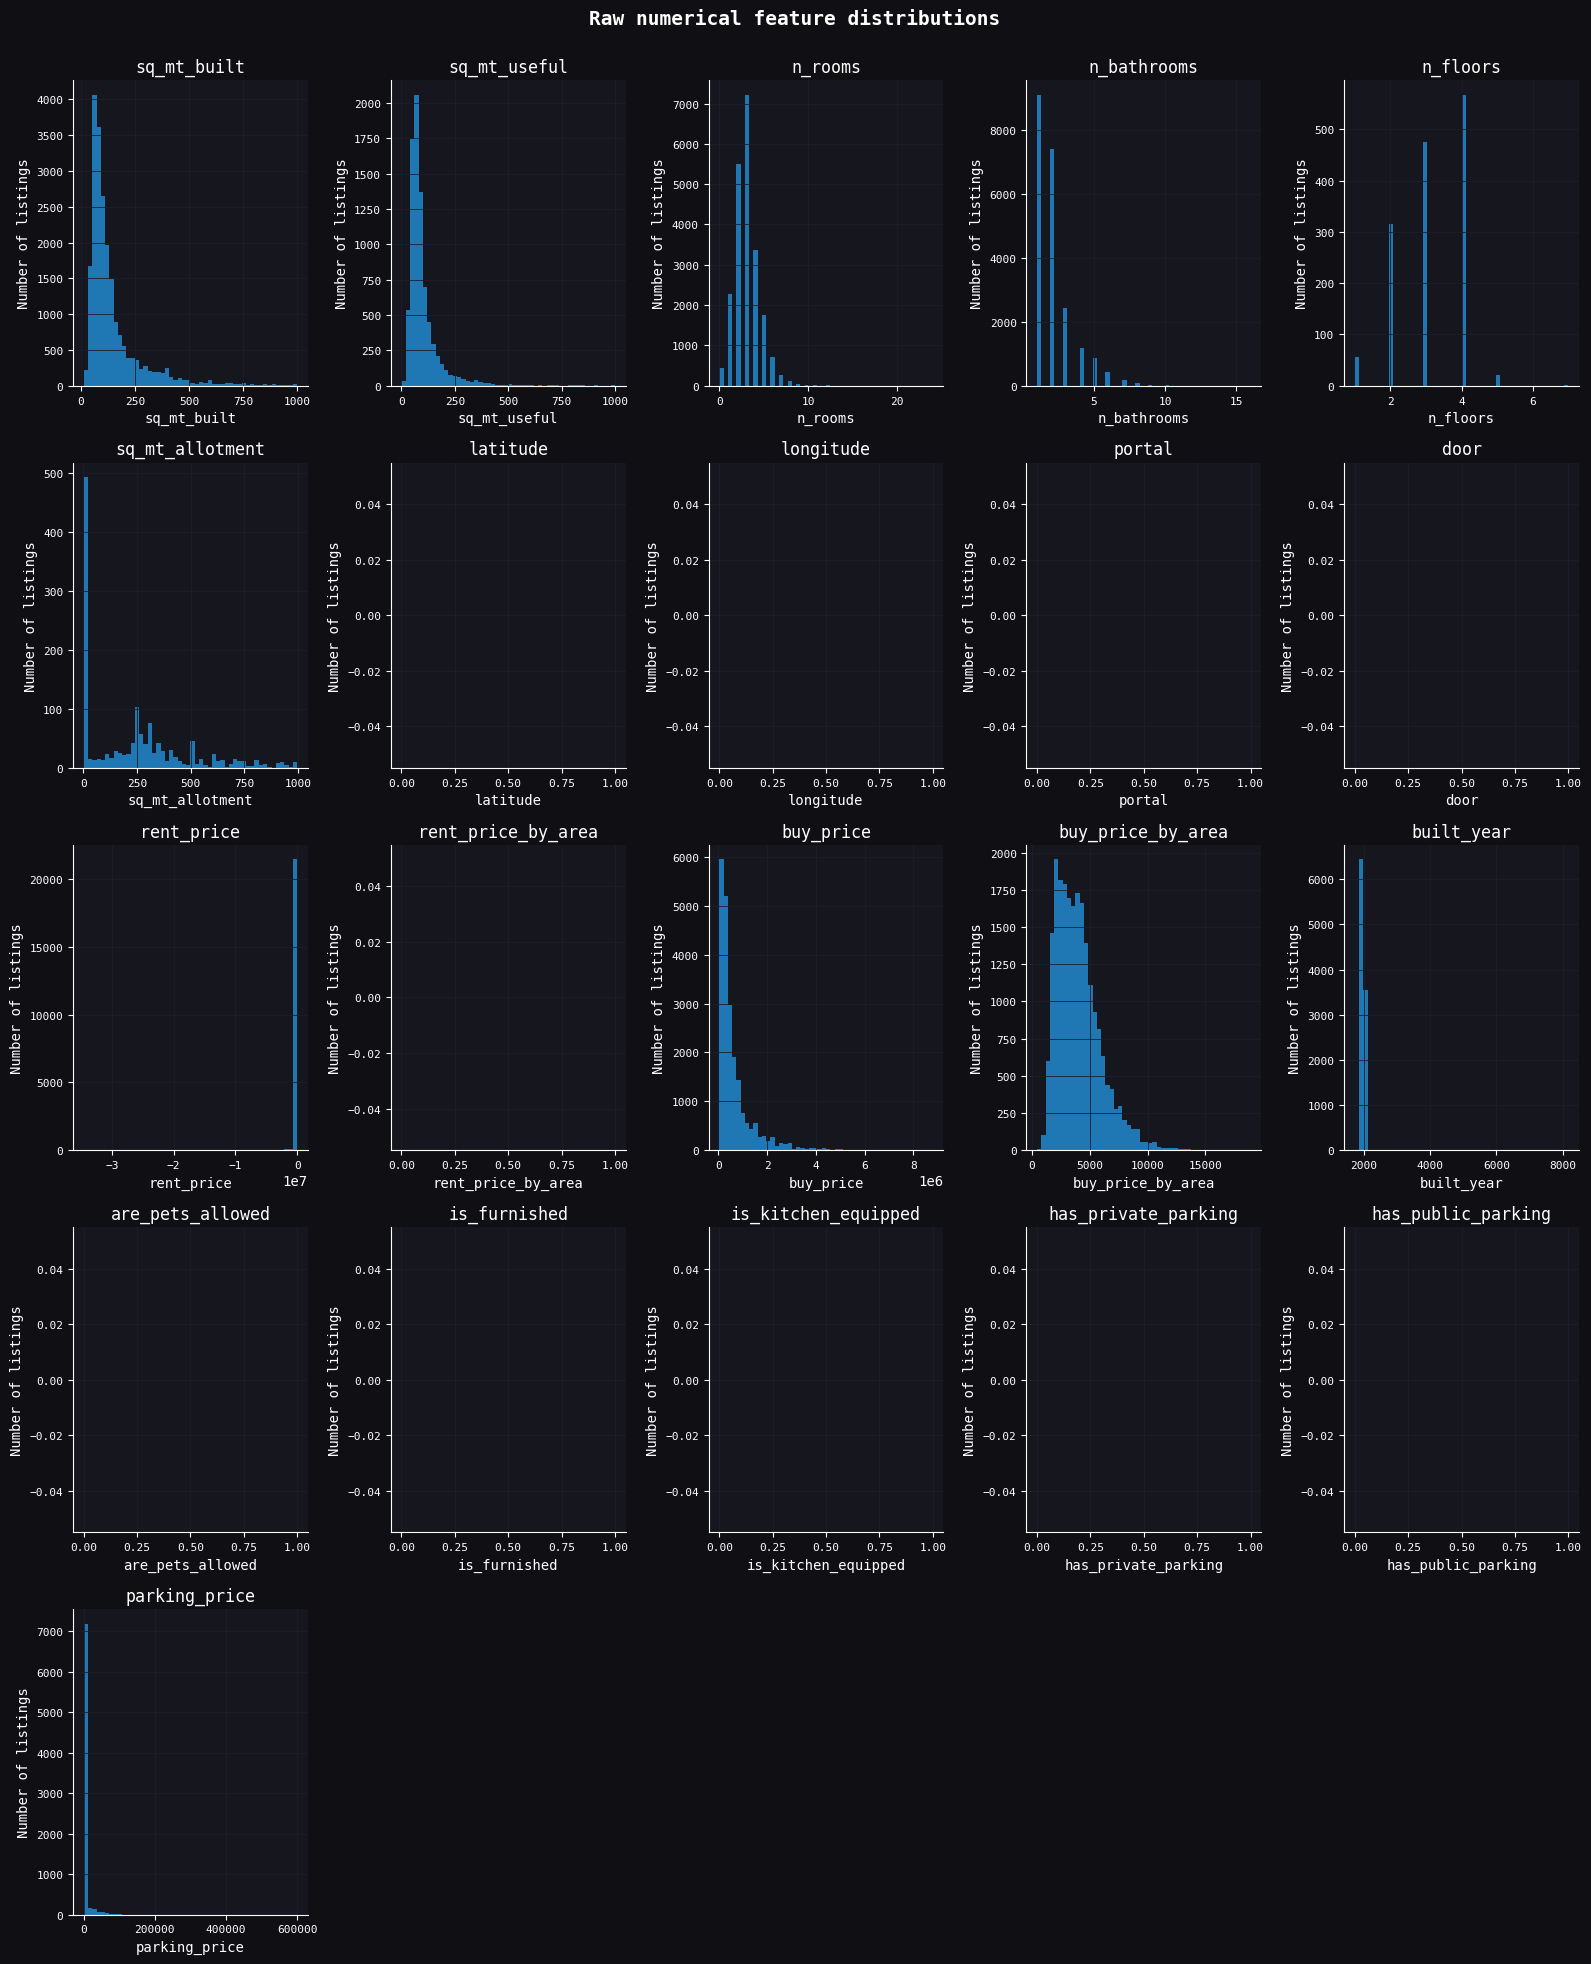

In [5]:
numeric_raw = df_raw.select_dtypes(include=[np.number]).drop(columns=["id"], errors="ignore")

if not numeric_raw.empty:
    axes = numeric_raw.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

    # pandas already uses each column name as the subplot title.
    # Here we also add explicit x/y axis labels so the grid is easier to read in the report.
    axes_array = np.ravel(axes) if isinstance(axes, np.ndarray) else np.array([axes])
    for ax, column in zip(axes_array, numeric_raw.columns):
        ax.set_xlabel(column)
        ax.set_ylabel("Number of listings")

    # Hide any unused subplot panels if the grid is larger than the number of numeric columns.
    for ax in axes_array[len(numeric_raw.columns):]:
        ax.set_visible(False)

    fig = axes_array[0].figure
    fig.suptitle("Raw numerical feature distributions", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No numerical columns available for histogram.")


In [6]:
assert not any(str(c).startswith("Unnamed") for c in df_raw.columns), "Accidental index column was not removed."
print("Accidental index columns removed correctly.")


Accidental index columns removed correctly.


## 2.4 Reading the raw numerical histograms

These histograms are an exploratory diagnostic of the raw numeric columns. They are not model results and they do not show feature importance. They show how each numeric variable is distributed before any modelling transformation.

The main patterns to look for are:

- **Right-skewed price and size variables:** most listings are relatively small or mid-priced, while a small number of luxury or unusually large properties create a long right tail. This is why the target `buy_price` is later modelled as `log1p(buy_price)`.
- **Sparse or almost-empty variables:** columns with little visible mass or very few non-missing observations are weak candidates for modelling because most of their values would have to be imputed.
- **Binary-like numeric flags:** some numeric columns only take values near 0 and 1. These should be interpreted as boolean indicators rather than continuous variables.
- **Potential outliers:** extreme values in variables such as price, built surface, or allotment surface deserve inspection. Outliers are not removed globally at this stage; the final workflow handles anomalies only on the training partition to avoid test leakage.
- **Possible redundancy:** variables that visually have very similar distributions, especially surface-related columns, may later be checked for high correlation and reduced to avoid duplicated signal.

For the report, the important conclusion is that the Madrid dataset is heterogeneous: the numeric variables are not normally distributed, several columns are sparse, and the target has a strong upper tail. That justifies careful preprocessing, log-transforming the target, and using tree-based models that can capture non-linear relationships.

# 3. Data Analysis

## 3.1 Preprocessing strategy

The notebook separates preprocessing into two groups:

1. **Safe pre-split operations:** deterministic operations such as duplicate removal and accidental index-column removal.
2. **Post-split operations fitted on training data only:** high-missingness column removal, imputation statistics, correlation-based feature dropping, dummy-variable schema, and outlier removal.

This separation prevents the test set from influencing preprocessing choices, model selection, or hyperparameter tuning. It also follows the course principle that operations such as scaling, imputation, feature extraction, feature selection, and synthetic data creation must be fitted after the split when they use dataset-level statistics.


In [7]:
TARGET = "buy_price"

AMENITY_COLS = [
    "has_ac",
    "has_fitted_wardrobes",
    "has_lift",
    "is_exterior",
    "has_pool",
    "has_terrace",
    "has_garden",
    "has_balcony",
    "has_storage_room",
    "is_accessible",
    "has_green_zones",
    "has_central_heating",
]

ORIENTATION_COLS = [
    "is_orientation_north",
    "is_orientation_south",
    "is_orientation_east",
    "is_orientation_west",
]

LEAKAGE_AND_ADMIN_COLS = [
    "id",
    "title",
    "subtitle",
    "street_name",
    "street_number",
    "portal",
    "rent_price",
    "rent_price_by_area",
    "is_rent_price_known",
    "buy_price_by_area",   # direct leakage: buy_price / sq_mt_built
    "is_buy_price_known",  # target-availability flag
]

ESSENTIAL_FEATURES = ["sq_mt_built", "n_bathrooms"]
REFERENCE_DUMMIES = ["house_type_id_Misc", "district_id_21"]

In [8]:
def clean_feature_names(X: pd.DataFrame) -> pd.DataFrame:
    """Make feature names compatible with tree-boosting libraries."""
    X = X.copy()
    X.columns = [
        re.sub(r"_+", "_", re.sub(r"[^A-Za-z0-9_]", "_", str(col))).strip("_")
        for col in X.columns
    ]

    # Cleaning may collapse two names into the same final string.
    if X.columns.duplicated().any():
        X = X.T.groupby(level=0).sum().T

    return X


def is_binary_series(s: pd.Series) -> bool:
    """Return True when a column is boolean-like, allowing missing values."""
    if pd.api.types.is_bool_dtype(s):
        return True

    non_null = s.dropna()
    if non_null.empty:
        return False

    try:
        return set(non_null.unique()).issubset({0, 1, True, False})
    except TypeError:
        return False


def columns_above_missing_threshold(df: pd.DataFrame, threshold: float = 0.60) -> list[str]:
    """
    Identify columns with too little usable signal.

    For non-binary numeric variables, zeros are treated as missing-like because several raw
    real-estate fields use zero as a placeholder for unrecorded values. Binary flags are protected
    because zero is a meaningful 'False' value.
    """
    missing_mask = df.isna().copy()

    binary_cols = [c for c in df.columns if is_binary_series(df[c])]
    non_binary_numeric = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in binary_cols
    ]

    if non_binary_numeric:
        missing_mask[non_binary_numeric] = (
            missing_mask[non_binary_numeric] | (df[non_binary_numeric] == 0)
        )

    missing_ratio = missing_mask.mean()
    return missing_ratio[missing_ratio > threshold].index.tolist()


def add_address_features(df: pd.DataFrame, col: str = "raw_address") -> pd.DataFrame:
    """Extract simple address-level features and remove the raw address string."""
    df = df.copy()
    if col not in df.columns:
        return df

    addr = df[col].fillna("").astype(str).str.strip()
    street_type = addr.str.extract(
        r"^(Calle|Avenida|Paseo|Plaza|Carretera|Camino|Cuesta|Ronda|Glorieta|Travesía|Travesia|Callejón|Callejon|Sector|Urbanización|Urbanizacion|Vía|Via)",
        flags=re.IGNORECASE,
    )[0]

    df["addr_street_type"] = street_type.str.title().fillna("Other")
    df["addr_has_number"] = addr.str.contains(r",?\s*\d+", regex=True).astype(int)

    number = pd.to_numeric(addr.str.extract(r",\s*(\d+)")[0], errors="coerce")
    df["addr_number_bucket"] = pd.cut(
        number,
        bins=[0, 10, 30, 60, 100, np.inf],
        labels=[1, 2, 3, 4, 5],
    ).astype(float).fillna(0)

    return df.drop(columns=[col], errors="ignore")


def add_location_features(df: pd.DataFrame, col: str = "neighborhood_id") -> pd.DataFrame:
    """Parse district and neighbourhood information from the raw location string."""
    df = df.copy()
    if col not in df.columns:
        return df

    s = df[col].fillna("").astype(str)

    df["district_id"] = (
        s.str.extract(r"District\s+(\d+)", flags=re.IGNORECASE)[0]
        .fillna("Unknown")
    )

    df["neighborhood_num"] = pd.to_numeric(
        s.str.extract(r"Neighborhood\s+(\d+)", flags=re.IGNORECASE)[0],
        errors="coerce",
    )

    # This is a location-level index embedded in the raw text, not buy_price_by_area for the row.
    df["neighborhood_price_m2"] = pd.to_numeric(
        s.str.extract(r"\(([\d.]+)\s*€/m2\)", flags=re.IGNORECASE)[0],
        errors="coerce",
    )

    return df.drop(columns=[col], errors="ignore")

In [9]:
def non_binary_numeric_columns(X: pd.DataFrame, min_unique: int = 20) -> list[str]:
    """Return numeric columns that are continuous enough for correlation filtering."""
    out = []
    for col in X.select_dtypes(include=[np.number]).columns:
        values = X[col].dropna()
        if values.nunique() >= min_unique:
            out.append(col)
    return out


def correlated_features_to_drop(
    X: pd.DataFrame,
    y_log: pd.Series,
    *,
    threshold: float = 0.98,
) -> list[str]:
    """
    Drop one feature from highly correlated continuous feature pairs.

    The decision is fitted on the training set only. For each highly correlated pair, the
    feature with the weaker absolute correlation to the log target is dropped.
    """
    candidate_cols = non_binary_numeric_columns(X)
    if len(candidate_cols) < 2:
        return []

    X_num = X[candidate_cols].copy()
    corr_matrix = X_num.corr().abs()
    target_corr = X_num.corrwith(y_log).abs().fillna(0)

    to_drop: set[str] = set()
    for i, col_i in enumerate(candidate_cols):
        if col_i in to_drop:
            continue
        for col_j in candidate_cols[i + 1:]:
            if col_j in to_drop:
                continue
            if corr_matrix.loc[col_i, col_j] > threshold:
                drop = col_i if target_corr[col_i] < target_corr[col_j] else col_j
                to_drop.add(drop)

    return sorted(to_drop)

In [10]:
@dataclass
class PreprocessSchema:
    drop_missing_cols: list[str]
    drop_correlated_cols: list[str]
    built_year_by_district: dict[str, float]
    built_year_global_median: float
    orientation_modes: dict[str, Any]
    numeric_medians: dict[str, float]
    train_columns: list[str]


def _base_feature_frame(
    df: pd.DataFrame,
    *,
    schema: PreprocessSchema | None = None,
    fit: bool = False,
    missing_threshold: float = 0.60,
) -> tuple[pd.DataFrame, pd.Series, dict[str, Any]]:
    """Internal helper used by fit_transform_features and transform_features."""
    data = df.copy()
    data = data.drop(columns=LEAKAGE_AND_ADMIN_COLS, errors="ignore")

    if fit:
        drop_missing_cols = columns_above_missing_threshold(data, threshold=missing_threshold)
    else:
        if schema is None:
            raise ValueError("schema is required when fit=False")
        drop_missing_cols = schema.drop_missing_cols

    data = data.drop(columns=drop_missing_cols, errors="ignore")
    data = add_location_features(data)
    data = add_address_features(data)

    required = [TARGET] + [c for c in ESSENTIAL_FEATURES if c in data.columns]
    data = data.dropna(subset=required)

    # In scraped listings, blank amenity fields usually mean "not advertised / not present".
    for col in AMENITY_COLS:
        if col in data.columns:
            data[col] = data[col].fillna(False).astype(int)

    if fit:
        orientation_modes = {}
        for col in ORIENTATION_COLS:
            if col in data.columns:
                mode = data[col].mode(dropna=True)
                orientation_modes[col] = mode.iloc[0] if not mode.empty else False
    else:
        orientation_modes = schema.orientation_modes if schema is not None else {}

    for col in ORIENTATION_COLS:
        if col in data.columns:
            data[col] = data[col].fillna(orientation_modes.get(col, False)).astype(int)

    if "is_new_development" in data.columns:
        data["is_new_development"] = data["is_new_development"].fillna(False).astype(int)

    if "house_type_id" in data.columns:
        data["house_type_id"] = data["house_type_id"].fillna("Misc")

    if fit:
        if "district_id" in data.columns and "built_year" in data.columns:
            built_year_by_district = data.groupby("district_id")["built_year"].median().dropna().to_dict()
        else:
            built_year_by_district = {}
        built_year_global_median = float(data["built_year"].median()) if "built_year" in data.columns else 1960.0
    else:
        built_year_by_district = schema.built_year_by_district if schema is not None else {}
        built_year_global_median = schema.built_year_global_median if schema is not None else 1960.0

    if "built_year" in data.columns:
        district_fill = data["district_id"].map(built_year_by_district) if "district_id" in data.columns else np.nan
        data["built_year"] = data["built_year"].fillna(district_fill).fillna(built_year_global_median)

    y = data[TARGET].copy()
    X = data.drop(columns=[TARGET], errors="ignore")
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X = X.drop(columns=REFERENCE_DUMMIES, errors="ignore")
    X = clean_feature_names(X)

    stats_out = {
        "drop_missing_cols": drop_missing_cols,
        "built_year_by_district": built_year_by_district,
        "built_year_global_median": built_year_global_median,
        "orientation_modes": orientation_modes,
    }
    return X, y, stats_out


def fit_transform_features(
    train_df: pd.DataFrame,
    *,
    missing_threshold: float = 0.60,
    correlation_threshold: float = 0.98,
) -> tuple[pd.DataFrame, pd.Series, PreprocessSchema]:
    """Fit all train-dependent preprocessing choices and transform the training data."""
    X, y, stats_out = _base_feature_frame(train_df, fit=True, missing_threshold=missing_threshold)

    numeric_medians = X.median(numeric_only=True).to_dict()
    X = X.fillna(numeric_medians).fillna(0)

    y_log_for_filter = np.log1p(y)
    drop_correlated_cols = correlated_features_to_drop(
        X,
        y_log_for_filter,
        threshold=correlation_threshold,
    )
    X = X.drop(columns=drop_correlated_cols, errors="ignore")

    schema = PreprocessSchema(
        drop_missing_cols=stats_out["drop_missing_cols"],
        drop_correlated_cols=drop_correlated_cols,
        built_year_by_district=stats_out["built_year_by_district"],
        built_year_global_median=stats_out["built_year_global_median"],
        orientation_modes=stats_out["orientation_modes"],
        numeric_medians=numeric_medians,
        train_columns=X.columns.tolist(),
    )
    return X.reset_index(drop=True), y.reset_index(drop=True), schema


def transform_features(test_df: pd.DataFrame, schema: PreprocessSchema) -> tuple[pd.DataFrame, pd.Series]:
    """Transform validation/test data using the already fitted training schema."""
    X, y, _ = _base_feature_frame(test_df, schema=schema, fit=False)

    X = X.fillna(schema.numeric_medians).fillna(0)
    X = X.drop(columns=schema.drop_correlated_cols, errors="ignore")
    X = X.reindex(columns=schema.train_columns, fill_value=0)

    return X.reset_index(drop=True), y.reset_index(drop=True)

## 3.2 Train/test split and leakage-safe preprocessing

The split is performed on the raw cleaned dataframe before any train-dependent transformations. The training partition fits the preprocessing schema, and the test partition is transformed using that same schema.

This design prevents the held-out set from influencing imputation statistics, dummy-variable creation, feature selection, correlation filtering, scaling, or any other preprocessing decision learned from data.

In [11]:
df_clean = df_raw.drop_duplicates().copy()

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

X_train, y_train_raw, preprocess_schema = fit_transform_features(
    train_df,
    missing_threshold=0.60,
    correlation_threshold=0.98,
)

X_test, y_test_raw = transform_features(test_df, preprocess_schema)

print(f"Training matrix before anomaly removal: {X_train.shape}")
print(f"Test matrix                            : {X_test.shape}")
print(f"Dropped high-missingness columns       : {len(preprocess_schema.drop_missing_cols)}")
print(f"Dropped correlated columns             : {len(preprocess_schema.drop_correlated_cols)}")
print(f"Remaining NaNs in X_train              : {int(X_train.isna().sum().sum())}")
print(f"Remaining NaNs in X_test               : {int(X_test.isna().sum().sum())}")

Training matrix before anomaly removal: (17287, 83)
Test matrix                            : (4313, 83)
Dropped high-missingness columns       : 19
Dropped correlated columns             : 0
Remaining NaNs in X_train              : 0
Remaining NaNs in X_test               : 0


## 3.3 Training-only anomaly detection

Isolation Forest is used conservatively to remove only the most extreme anomalous rows from the **training set**. The held-out test set is not filtered, because it must represent the kind of unseen market data the final model will face.

The anomaly detector is fitted only on the training partition after leakage-safe preprocessing. Removing a very small number of extreme training observations can reduce the influence of potential data-entry errors or highly unusual listings while preserving the natural variability of the Madrid housing market.

In [12]:
def remove_training_anomalies(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    n_to_remove: int = 50,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """Remove the most extreme anomalies from the training set only."""
    if n_to_remove <= 0 or len(X) < 100:
        empty = pd.DataFrame(columns=["row_position", "anomaly_score"])
        return X.reset_index(drop=True), y.reset_index(drop=True), empty

    n_to_remove = min(n_to_remove, len(X) - 1)
    contamination = min(0.01, max(n_to_remove / len(X), 0.001))

    detector = IsolationForest(contamination=contamination, random_state=random_state)
    detector.fit(X)

    scores = detector.decision_function(X)
    remove_positions = np.argsort(scores)[:n_to_remove]

    keep_mask = np.ones(len(X), dtype=bool)
    keep_mask[remove_positions] = False

    removed = pd.DataFrame({
        "row_position": remove_positions,
        "anomaly_score": scores[remove_positions],
    }).sort_values("anomaly_score")

    return (
        X.iloc[keep_mask].reset_index(drop=True),
        y.iloc[keep_mask].reset_index(drop=True),
        removed,
    )


X_train, y_train_raw, removed_anomalies = remove_training_anomalies(
    X_train,
    y_train_raw,
    n_to_remove=50,
)

y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

print(f"Training matrix after anomaly removal: {X_train.shape}")
print(f"Removed training anomalies           : {len(removed_anomalies)}")
display(removed_anomalies.head())

Training matrix after anomaly removal: (17237, 83)
Removed training anomalies           : 50


,row_position,anomaly_score
0,16723,-0.030341
1,3867,-0.025143
2,15049,-0.025063
3,4171,-0.022338
4,880,-0.021289


## 3.4 Exploratory data analysis on the training partition

The following plots support the report figures and the modelling choices:

1. raw vs. log-transformed target distribution,
2. price vs. built surface,
3. strongest correlations with log-price,
4. median price by district,
5. columns with highest raw missingness.

The plots use the training partition so that exploratory model decisions are not informed by the held-out test data.

Saved → plots/target_distribution.png


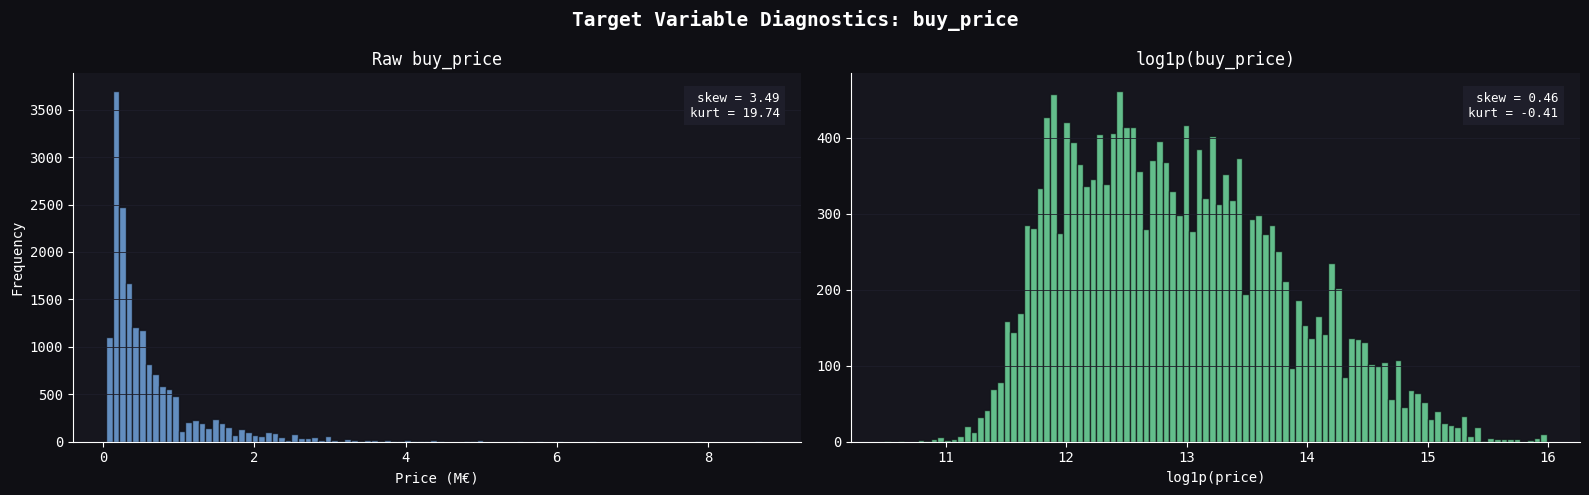

In [13]:
def save_figure(fig: plt.Figure, filename: str) -> None:
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved → {path}")


def plot_target_distribution(y_raw: pd.Series) -> plt.Figure:
    y_clean = y_raw.dropna()
    y_log = np.log1p(y_clean)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor="#0f0f14")
    fig.suptitle("Target Variable Diagnostics: buy_price", fontsize=14, fontweight="bold")

    axes[0].hist(y_clean / 1e6, bins=100, color=ACCENT, alpha=0.75, edgecolor="#0f0f14")
    axes[0].set_title("Raw buy_price")
    axes[0].set_xlabel("Price (M€)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, axis="y")
    axes[0].text(
        0.97,
        0.95,
        f"skew = {stats.skew(y_clean):.2f}\nkurt = {stats.kurtosis(y_clean):.2f}",
        transform=axes[0].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4),
    )

    axes[1].hist(y_log, bins=100, color=ACCENT3, alpha=0.75, edgecolor="#0f0f14")
    axes[1].set_title("log1p(buy_price)")
    axes[1].set_xlabel("log1p(price)")
    axes[1].grid(True, axis="y")
    axes[1].text(
        0.97,
        0.95,
        f"skew = {stats.skew(y_log):.2f}\nkurt = {stats.kurtosis(y_log):.2f}",
        transform=axes[1].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4),
    )

    fig.tight_layout()
    return fig


fig = plot_target_distribution(y_train_raw)
save_figure(fig, "target_distribution.png")
plt.show()

Saved → plots/eda_summary.png


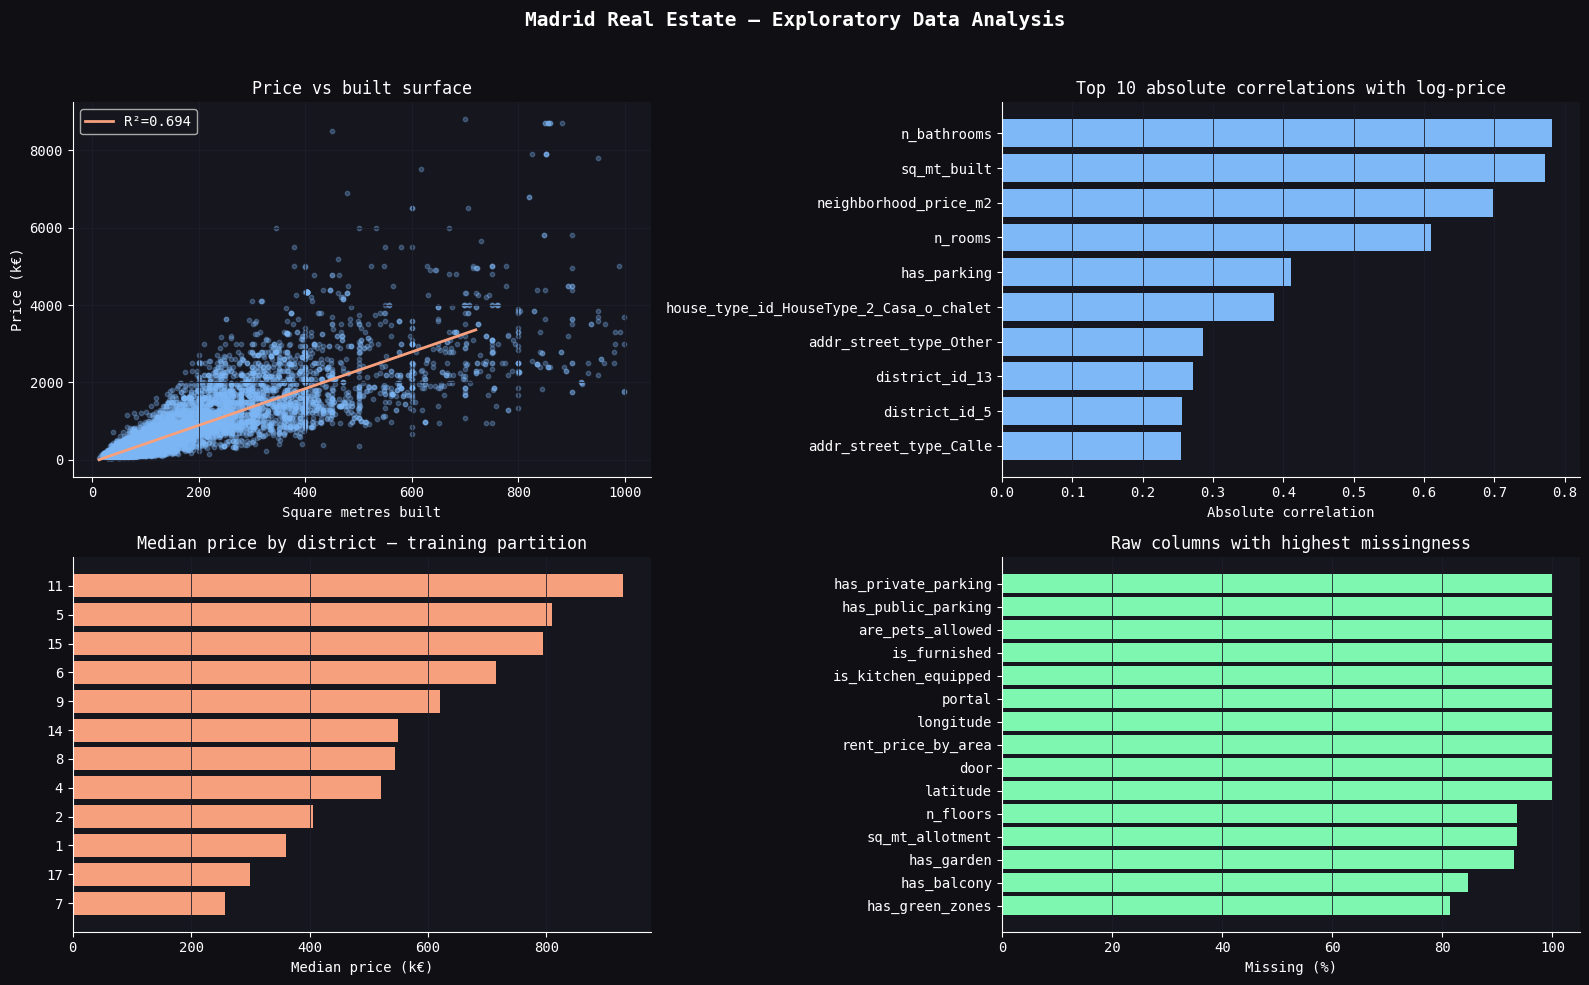

In [14]:
def plot_eda_summary(X: pd.DataFrame, y_log: pd.Series, raw_train_df: pd.DataFrame) -> plt.Figure:
    """Create the main EDA figure using only the training partition."""
    y_euros = np.expm1(y_log)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#0f0f14")
    fig.suptitle("Madrid Real Estate — Exploratory Data Analysis", fontsize=14, fontweight="bold")

    ax = axes[0, 0]
    if "sq_mt_built" in X.columns:
        x = X["sq_mt_built"]
        ax.scatter(x, y_euros / 1e3, s=10, alpha=0.3, color=ACCENT, rasterized=True)
        valid = ~(x.isna() | y_euros.isna())
        if valid.sum() > 2:
            slope, intercept, r_value, _, _ = stats.linregress(x[valid], y_euros[valid] / 1e3)
            x_line = np.array([x.min(), x.quantile(0.99)])
            ax.plot(x_line, slope * x_line + intercept, color=ACCENT2, lw=2, label=f"R²={r_value**2:.3f}")
            ax.legend()
    ax.set_title("Price vs built surface")
    ax.set_xlabel("Square metres built")
    ax.set_ylabel("Price (k€)")
    ax.grid(True)

    ax = axes[0, 1]
    corr = X.corrwith(y_log).abs().sort_values().tail(10)
    ax.barh(corr.index, corr.values, color=ACCENT)
    ax.set_title("Top 10 absolute correlations with log-price")
    ax.set_xlabel("Absolute correlation")
    ax.grid(True, axis="x")

    ax = axes[1, 0]
    train_with_district = add_location_features(raw_train_df.copy())
    if {"district_id", TARGET}.issubset(train_with_district.columns):
        district_median = (
            train_with_district.dropna(subset=[TARGET])
            .groupby("district_id")[TARGET]
            .median()
            .sort_values()
            .tail(12)
            / 1e3
        )
        ax.barh(district_median.index.astype(str), district_median.values, color=ACCENT2)
    ax.set_title("Median price by district — training partition")
    ax.set_xlabel("Median price (k€)")
    ax.grid(True, axis="x")

    ax = axes[1, 1]
    missing_pct = (raw_train_df.isna().mean() * 100).sort_values().tail(15)
    ax.barh(missing_pct.index, missing_pct.values, color=ACCENT3)
    ax.set_title("Raw columns with highest missingness")
    ax.set_xlabel("Missing (%)")
    ax.grid(True, axis="x")

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


fig = plot_eda_summary(X_train, y_train, train_df)
save_figure(fig, "eda_summary.png")
plt.show()


### District-level price distribution

District is one of the strongest economic drivers of housing prices. The box plot below shows not only median price differences between districts, but also the spread, skewness, and outliers within each district.

The plot is computed only on the training partition, so it is an exploratory diagnostic and does not leak information from the held-out test set into modelling.

/tmp/ipykernel_70443/1822253892.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved → plots/district_price_boxplot_train.png


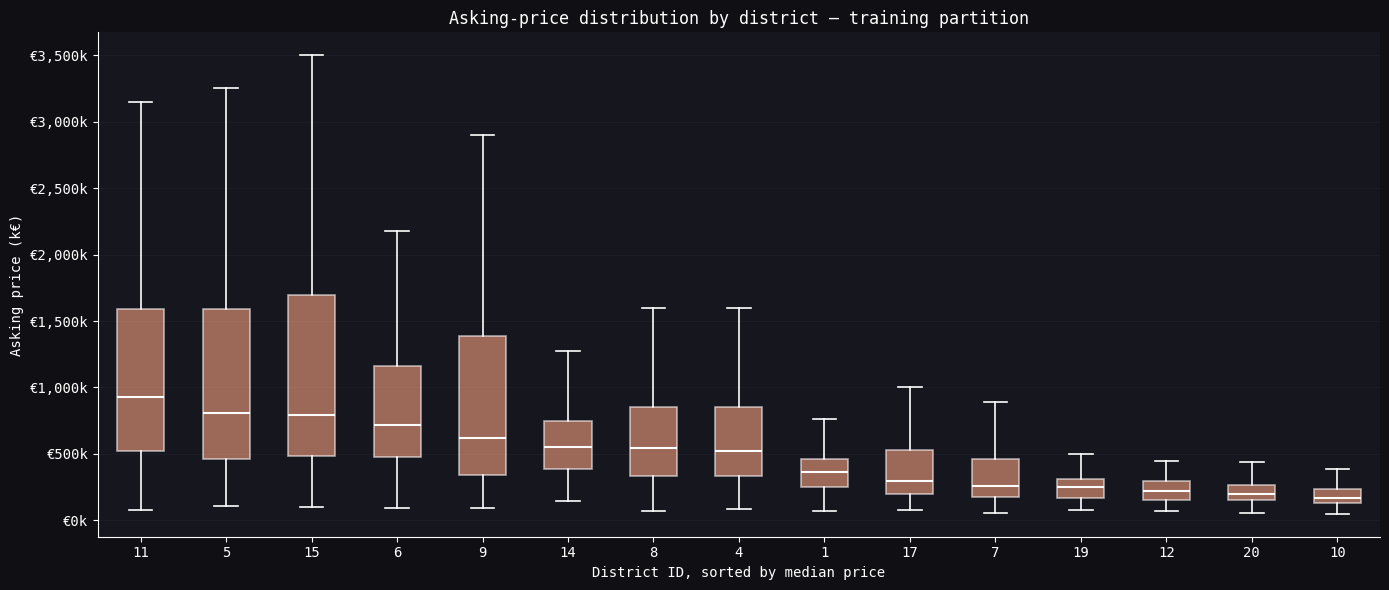

In [15]:
def plot_district_price_boxplot(
    raw_train_df: pd.DataFrame,
    *,
    min_listings: int = 50,
    top_n: int = 15,
) -> plt.Figure:
    """Plot price distributions by district using only the training partition."""
    district_df = add_location_features(raw_train_df.copy())

    required = {"district_id", TARGET}
    if not required.issubset(district_df.columns):
        raise ValueError(f"Missing required columns for district boxplot: {required - set(district_df.columns)}")

    district_df = district_df.dropna(subset=["district_id", TARGET]).copy()
    district_df["price_k_eur"] = district_df[TARGET] / 1e3

    counts = district_df["district_id"].value_counts()
    valid_districts = counts[counts >= min_listings].index
    district_df = district_df[district_df["district_id"].isin(valid_districts)]

    median_order = (
        district_df.groupby("district_id")["price_k_eur"]
        .median()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .astype(str)
        .tolist()
    )

    data = [district_df.loc[district_df["district_id"].astype(str) == d, "price_k_eur"].values for d in median_order]

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="#0f0f14")
    bp = ax.boxplot(
        data,
        labels=median_order,
        patch_artist=True,
        showfliers=False,
        widths=0.55,
        medianprops=dict(color="#ffffff", lw=1.5),
        boxprops=dict(color="#ffffff", linewidth=1.2),
        whiskerprops=dict(color="#ffffff", linewidth=1.2),
        capprops=dict(color="#ffffff", linewidth=1.2),
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(ACCENT2)
        patch.set_alpha(0.6)

    ax.set_title("Asking-price distribution by district — training partition")
    ax.set_xlabel("District ID, sorted by median price")
    ax.set_ylabel("Asking price (k€)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}k"))
    ax.grid(True, axis="y")
    fig.tight_layout()
    return fig


fig = plot_district_price_boxplot(train_df)
save_figure(fig, "district_price_boxplot_train.png")
plt.show()

## 3.5 Evaluation metrics

Models are trained on the log target, but metrics are converted back to euros for interpretation. This keeps the optimisation stable while preserving stakeholder-readable results.

In [16]:
def to_euros(y_log: np.ndarray | pd.Series) -> np.ndarray:
    return np.expm1(np.asarray(y_log))


def rmse_euros(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    return math.sqrt(mean_squared_error(to_euros(y_true_log), to_euros(y_pred_log)))


def mae_euros(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    return mean_absolute_error(to_euros(y_true_log), to_euros(y_pred_log))


def medae_euros(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    return median_absolute_error(to_euros(y_true_log), to_euros(y_pred_log))


def mape_pct(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    y_true = to_euros(y_true_log)
    y_pred = to_euros(y_pred_log)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def medape_pct(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    y_true = to_euros(y_true_log)
    y_pred = to_euros(y_pred_log)
    return float(np.median(np.abs((y_true - y_pred) / y_true)) * 100)


def r2_euros(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> float:
    return r2_score(to_euros(y_true_log), to_euros(y_pred_log))


SCORING = {
    "r2_log": "r2",
    "r2_euros": make_scorer(r2_euros),
    "mae": make_scorer(mae_euros, greater_is_better=False),
    "medae": make_scorer(medae_euros, greater_is_better=False),
    "rmse": make_scorer(rmse_euros, greater_is_better=False),
    "mape": make_scorer(mape_pct, greater_is_better=False),
    "medape": make_scorer(medape_pct, greater_is_better=False),
}


def evaluate_log_predictions(y_true_log: pd.Series, y_pred_log: np.ndarray) -> dict[str, float]:
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "R2_euros": r2_euros(y_true_log, y_pred_log),
        "MAE_euros": mae_euros(y_true_log, y_pred_log),
        "MedAE_euros": medae_euros(y_true_log, y_pred_log),
        "RMSE_euros": rmse_euros(y_true_log, y_pred_log),
        "MAPE_pct": mape_pct(y_true_log, y_pred_log),
        "MedAPE_pct": medape_pct(y_true_log, y_pred_log),
    }

# 4. Model Selection and Statistical Comparison

## 4.1 Baseline model comparison

The first comparison uses default configurations of candidate models. This provides a quick ranking before hyperparameter tuning. The comparison is performed only on the training set through cross-validation.

In [ ]:
def available_baseline_models() -> dict[str, Any]:
    models: dict[str, Any] = {
        "DummyMean": DummyRegressor(strategy="mean"),
        "LinearRegression": LinearRegression(),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        "ElasticNet": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=3_000, random_state=RANDOM_STATE)),
        ]),
        "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    if xgb is not None:
        models["XGBoost"] = xgb.XGBRegressor(
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbosity=0,
            eval_metric="rmse",
        )

    if lgb is not None:
        models["LightGBM"] = lgb.LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=-1,
            force_row_wise=True,
        )

    return models


def cross_validate_model_table(
    models: dict[str, Any],
    X: pd.DataFrame,
    y: pd.Series,
    *,
    cv: KFold,
) -> pd.DataFrame:
    rows = []

    for name, model in models.items():
        start = time.perf_counter()
        result = cross_validate(model, X, y, scoring=SCORING, cv=cv, n_jobs=N_JOBS)
        duration = time.perf_counter() - start

        rows.append({
            "model": name,
            "R2_log": result["test_r2_log"].mean(),
            "R2_euros": result["test_r2_euros"].mean(),
            "MAE_euros": -result["test_mae"].mean(),
            "MedAE_euros": -result["test_medae"].mean(),
            "RMSE_euros": -result["test_rmse"].mean(),
            "MAPE_pct": -result["test_mape"].mean(),
            "MedAPE_pct": -result["test_medape"].mean(),
            "fit_time_s": duration,
        })

    return pd.DataFrame(rows).sort_values("RMSE_euros").reset_index(drop=True)


baseline_cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
baseline_results = cross_validate_model_table(
    available_baseline_models(),
    X_train,
    y_train,
    cv=baseline_cv,
)

display(baseline_results)

## 4.2 Nested cross-validation for model selection

Nested cross-validation is used because hyperparameter tuning is itself a learning process. The inner loop chooses hyperparameters, while the outer loop estimates how well the tuned modelling procedure generalises within the training data.

Set `FAST_MODE=True` while debugging. For the complete model-selection run, keep `FAST_MODE=False`.

In [ ]:
FAST_MODE = False
FAST_SAMPLE_SIZE = 3_000
MODELS_TO_RUN: list[str] | None = None  # Example: ["RandomForest", "LightGBM"]


def make_model_configs() -> dict[str, dict[str, Any]]:
    configs: dict[str, dict[str, Any]] = {
        "Ridge": {
            "estimator": Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
            "params_full": {"model__alpha": np.logspace(-2, 4, 50)},
            "params_fast": {"model__alpha": np.logspace(-1, 3, 10)},
            "n_iter_full": 20,
            "n_iter_fast": 8,
        },
        "ElasticNet": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("model", ElasticNet(max_iter=10_000, random_state=RANDOM_STATE)),
            ]),
            "params_full": {
                "model__alpha": np.logspace(-3, 2, 40),
                "model__l1_ratio": np.linspace(0.1, 0.9, 9),
            },
            "params_fast": {
                "model__alpha": np.logspace(-2, 1, 8),
                "model__l1_ratio": [0.2, 0.5, 0.8],
            },
            "n_iter_full": 20,
            "n_iter_fast": 8,
        },
        "RandomForest": {
            "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
            "params_full": {
                "n_estimators": [300, 600, 900],
                "max_depth": [15, 25, None],
                "min_samples_leaf": [1, 5, 10, 20],
                "min_samples_split": [2, 5, 10],
                "max_features": ["sqrt", "log2", None],
            },
            "params_fast": {
                "n_estimators": [200, 400],
                "max_depth": [15, None],
                "min_samples_leaf": [5, 10],
            },
            "n_iter_full": 20,
            "n_iter_fast": 8,
        },
        "GradientBoosting": {
            "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
            "params_full": {
                "n_estimators": [200, 400, 600],
                "learning_rate": [0.01, 0.05, 0.1],
                "max_depth": [3, 4, 5],
                "subsample": [0.7, 0.8, 1.0],
                "min_samples_leaf": [5, 10, 20, 30],
            },
            "params_fast": {
                "n_estimators": [150, 250],
                "learning_rate": [0.05, 0.1],
                "max_depth": [3, 4],
            },
            "n_iter_full": 20,
            "n_iter_fast": 8,
        },
    }

    if xgb is not None:
        configs["XGBoost"] = {
            "estimator": xgb.XGBRegressor(
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
                verbosity=0,
                eval_metric="rmse",
            ),
            "params_full": {
                "n_estimators": [300, 500, 800],
                "learning_rate": [0.01, 0.05, 0.1],
                "max_depth": [4, 5, 6, 7],
                "subsample": [0.7, 0.8, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
                "reg_alpha": [0, 0.1, 0.5, 1.0],
                "reg_lambda": [0.5, 1.0, 2.0],
                "min_child_weight": [1, 5, 10],
            },
            "params_fast": {
                "n_estimators": [200, 400],
                "learning_rate": [0.05, 0.1],
                "max_depth": [4, 6],
                "reg_alpha": [0, 0.1],
            },
            "n_iter_full": 25,
            "n_iter_fast": 8,
        }

    if lgb is not None:
        configs["LightGBM"] = {
            "estimator": lgb.LGBMRegressor(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
                verbose=-1,
                force_row_wise=True,
            ),
            "params_full": {
                "n_estimators": [300, 500, 800],
                "learning_rate": [0.01, 0.05, 0.1],
                "max_depth": [-1, 10, 20],
                "num_leaves": [31, 63, 127],
                "subsample": [0.7, 0.8, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
                "reg_alpha": [0, 0.1, 0.5],
                "reg_lambda": [0, 0.1, 1.0],
                "min_child_samples": [10, 20, 30],
            },
            "params_fast": {
                "n_estimators": [200, 400],
                "learning_rate": [0.05, 0.1],
                "num_leaves": [31, 63],
                "reg_lambda": [0, 0.1],
            },
            "n_iter_full": 25,
            "n_iter_fast": 8,
        }

    if MODELS_TO_RUN is not None:
        configs = {k: v for k, v in configs.items() if k in MODELS_TO_RUN}

    return configs


def stratified_regression_sample(
    X: pd.DataFrame,
    y: pd.Series,
    sample_size: int,
) -> tuple[pd.DataFrame, pd.Series]:
    """Subsample while preserving the target distribution across quantile bins."""
    if len(X) <= sample_size:
        return X.reset_index(drop=True), y.reset_index(drop=True)

    bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
    rng = np.random.default_rng(RANDOM_STATE)
    chosen: list[int] = []
    per_bin = max(1, sample_size // max(1, pd.Series(bins).nunique()))

    for _, idx in pd.Series(np.arange(len(y))).groupby(bins):
        idx_values = idx.to_numpy()
        size = min(len(idx_values), per_bin)
        chosen.extend(rng.choice(idx_values, size=size, replace=False).tolist())

    chosen = np.array(sorted(set(chosen)))
    return X.iloc[chosen].reset_index(drop=True), y.iloc[chosen].reset_index(drop=True)


def run_nested_cv(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    fast_mode: bool = FAST_MODE,
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    configs = make_model_configs()
    X_run, y_run = stratified_regression_sample(X, y, FAST_SAMPLE_SIZE) if fast_mode else (X, y)

    outer_cv = KFold(n_splits=3 if fast_mode else 5, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = KFold(n_splits=2 if fast_mode else 3, shuffle=True, random_state=RANDOM_STATE)
    rmse_scorer = make_scorer(rmse_euros, greater_is_better=False)

    print(f"Mode: {'FAST' if fast_mode else 'FULL'} | rows: {len(X_run):,} | models: {', '.join(configs)}")
    rows = []

    for name, cfg in configs.items():
        params = cfg["params_fast"] if fast_mode else cfg["params_full"]
        n_iter = cfg["n_iter_fast"] if fast_mode else cfg["n_iter_full"]

        print(f"Running {name} ...")
        search = RandomizedSearchCV(
            estimator=cfg["estimator"],
            param_distributions=params,
            n_iter=n_iter,
            cv=inner_cv,
            scoring=rmse_scorer,
            refit=True,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

        # Keep outer parallelism at 1 to avoid nested parallel oversubscription.
        outer_result = cross_validate(
            search,
            X_run,
            y_run,
            cv=outer_cv,
            scoring=SCORING,
            n_jobs=1,
            return_train_score=False,
        )

        # Fit one final search on the training data used in this mode to recover candidate params.
        search.fit(X_run, y_run)

        rows.append({
            "model": name,
            "RMSE_euros_mean": -outer_result["test_rmse"].mean(),
            "RMSE_euros_std": outer_result["test_rmse"].std(),
            "MAE_euros_mean": -outer_result["test_mae"].mean(),
            "MedAE_euros_mean": -outer_result["test_medae"].mean(),
            "MAPE_pct_mean": -outer_result["test_mape"].mean(),
            "R2_log_mean": outer_result["test_r2_log"].mean(),
            "best_params": search.best_params_,
        })

    results = pd.DataFrame(rows).sort_values("RMSE_euros_mean").reset_index(drop=True)
    return results, configs


nested_results, model_configs = run_nested_cv(X_train, y_train, fast_mode=FAST_MODE)
display(nested_results)

In [ ]:
def build_model_from_config(model_name: str, params: dict[str, Any] | None = None) -> Any:
    """Rebuild one candidate model from the configuration dictionary and tuned parameters."""
    configs = make_model_configs()
    if model_name not in configs:
        raise KeyError(f"Unknown model: {model_name}")

    model = clone(configs[model_name]["estimator"])
    if params:
        model.set_params(**params)

    return model

## 4.3 Statistical comparison before using the test set

The paired t-test belongs here, before the final held-out test evaluation, because it is part of model comparison rather than final model assessment.

The test uses fold-level RMSE values from the same cross-validation splits. This makes the observations paired: fold 1 for model A is compared with fold 1 for model B, fold 2 with fold 2, and so on.

This is a secondary robustness check, not the main proof of superiority. Standard paired t-tests on k-fold CV scores should be interpreted cautiously because the folds overlap and are not perfectly independent. Holm correction is used for multiple pairwise comparisons.

In [ ]:
def paired_cv_scores(
    models: dict[str, Any],
    X: pd.DataFrame,
    y: pd.Series,
    *,
    cv: KFold,
) -> pd.DataFrame:
    """Return paired RMSE scores, one column per model and one row per CV fold."""
    rmse_scorer = make_scorer(rmse_euros, greater_is_better=False)
    fold_scores = {}

    for name, model in models.items():
        result = cross_validate(model, X, y, scoring=rmse_scorer, cv=cv, n_jobs=N_JOBS)
        fold_scores[name] = -result["test_score"]

    return pd.DataFrame(fold_scores)


def holm_correct(p_values: list[float]) -> list[float]:
    """Holm-Bonferroni correction for multiple pairwise tests."""
    p = np.asarray(p_values, dtype=float)
    p = np.where(np.isnan(p), 1.0, p)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running_max = 0.0
    m = len(p)

    for rank, idx in enumerate(order):
        value = min((m - rank) * p[idx], 1.0)
        running_max = max(running_max, value)
        adjusted[idx] = running_max

    return adjusted.tolist()


def paired_ttest_table(score_df: pd.DataFrame) -> pd.DataFrame:
    """Pairwise paired t-tests over paired fold-level RMSE scores."""
    rows = []

    for a, b in itertools.combinations(score_df.columns, 2):
        diff_values = score_df[a] - score_df[b]
        diff_mean = float(diff_values.mean())
        diff_std = float(diff_values.std(ddof=1))

        if np.isclose(diff_std, 0.0):
            t_stat = 0.0
            p_value = 1.0
            cohen_dz = 0.0
        else:
            t_stat, p_value = stats.ttest_rel(score_df[a], score_df[b])
            cohen_dz = diff_mean / diff_std

        rows.append({
            "model_a": a,
            "model_b": b,
            "mean_rmse_a": score_df[a].mean(),
            "mean_rmse_b": score_df[b].mean(),
            "mean_diff_a_minus_b": diff_mean,
            "cohen_dz": cohen_dz,
            "t_stat": t_stat,
            "p_value": p_value,
            "lower_mean_error": a if diff_mean < 0 else b,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_holm"] = holm_correct(out["p_value"].tolist())
        out = out.sort_values(["p_holm", "p_value"]).reset_index(drop=True)

    return out


selected_names = nested_results["model"].head(min(4, len(nested_results))).tolist()
models_for_ttest = {
    name: build_model_from_config(
        name,
        nested_results.loc[nested_results["model"] == name, "best_params"].iloc[0],
    )
    for name in selected_names
}

paired_cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
fold_rmse = paired_cv_scores(models_for_ttest, X_train, y_train, cv=paired_cv)
ttest_results = paired_ttest_table(fold_rmse)

print("Paired t-test check uses only X_train / y_train. The held-out test set is still unused.")
print("Per-fold RMSE (€):")
display(fold_rmse.round(0))

print("Pairwise paired t-tests with Holm correction:")
display(ttest_results.round({
    "mean_rmse_a": 0,
    "mean_rmse_b": 0,
    "mean_diff_a_minus_b": 0,
    "cohen_dz": 3,
    "t_stat": 3,
    "p_value": 4,
    "p_holm": 4,
}))

In [ ]:
def plot_fold_score_distribution(score_df: pd.DataFrame) -> plt.Figure:
    order = score_df.mean().sort_values().index.tolist()
    data = [score_df[col].values for col in order]

    fig, ax = plt.subplots(figsize=(10, 5), facecolor="#0f0f14")
    bp = ax.boxplot(
        data,
        labels=order,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="#ffffff", lw=1.5),
        boxprops=dict(color="#ffffff", linewidth=1.2),
        whiskerprops=dict(color="#ffffff", linewidth=1.2),
        capprops=dict(color="#ffffff", linewidth=1.2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4, markerfacecolor="#ffffff", markeredgecolor="#ffffff"),
    )

    palette = [ACCENT, ACCENT3, "#f7d77e", ACCENT2]
    for patch, color in zip(bp["boxes"], palette * 3):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    rng = np.random.default_rng(RANDOM_STATE)
    for i, vals in enumerate(data, start=1):
        ax.scatter(rng.normal(i, 0.04, len(vals)), vals, color="#ffffff", alpha=0.7, s=22, zorder=3)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax.set_ylabel("RMSE per fold")
    ax.set_title("10-fold CV RMSE per selected model — lower is better")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


fig = plot_fold_score_distribution(fold_rmse)
save_figure(fig, "paired_cv_rmse_distribution.png")
plt.show()

## 4.4 Learning curve -> over/underfitting diagnostic

Before evaluating the final model on the held-out test set, a learning curve is computed using cross-validation on the training partition only. It compares training error and validation error across increasing training-set sizes.

This diagnostic helps assess whether the selected model appears mainly limited by bias, variance, or insufficient data, while keeping the held-out test set reserved for final assessment.


In [ ]:
def plot_learning_curve_rmse(
    estimator: Any,
    X: pd.DataFrame,
    y: pd.Series,
    *,
    cv: KFold,
    train_sizes: np.ndarray | None = None,
) -> tuple[plt.Figure, pd.DataFrame]:
    """Plot train-vs-validation RMSE learning curves on the training partition only."""
    if train_sizes is None:
        train_sizes = np.linspace(0.15, 1.0, 6)

    rmse_scorer = make_scorer(rmse_euros, greater_is_better=False)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=rmse_scorer,
        train_sizes=train_sizes,
        n_jobs=1,  # avoid nested parallelism when the estimator also uses n_jobs=-1
        shuffle=False,
    )

    train_rmse = -train_scores
    val_rmse = -val_scores

    summary = pd.DataFrame({
        "train_size": train_sizes_abs,
        "train_rmse_mean": train_rmse.mean(axis=1),
        "train_rmse_std": train_rmse.std(axis=1),
        "validation_rmse_mean": val_rmse.mean(axis=1),
        "validation_rmse_std": val_rmse.std(axis=1),
    })

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="#0f0f14")
    ax.plot(summary["train_size"], summary["train_rmse_mean"], marker="o", label="Training RMSE", color=ACCENT)
    ax.fill_between(
        summary["train_size"],
        summary["train_rmse_mean"] - summary["train_rmse_std"],
        summary["train_rmse_mean"] + summary["train_rmse_std"],
        alpha=0.15,
        color=ACCENT,
    )

    ax.plot(summary["train_size"], summary["validation_rmse_mean"], marker="o", label="CV validation RMSE", color=ACCENT2)
    ax.fill_between(
        summary["train_size"],
        summary["validation_rmse_mean"] - summary["validation_rmse_std"],
        summary["validation_rmse_mean"] + summary["validation_rmse_std"],
        alpha=0.15,
        color=ACCENT2,
    )

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax.set_title(f"Learning curve — {winner_name}")
    ax.set_xlabel("Number of training examples")
    ax.set_ylabel("RMSE in euros")
    ax.grid(True, axis="y")
    ax.legend()
    fig.tight_layout()

    return fig, summary


learning_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
winner_name = nested_results.loc[0, "model"]
winner_params = nested_results.loc[0, "best_params"]
selected_model_for_diagnostics = build_model_from_config(winner_name, winner_params)

fig, learning_curve_summary = plot_learning_curve_rmse(selected_model_for_diagnostics, X_train, y_train, cv=learning_cv)
save_figure(fig, "final_learning_curve_train_cv.png")
plt.show()

display(learning_curve_summary.round(0))

final_gap = learning_curve_summary.iloc[-1]["validation_rmse_mean"] - learning_curve_summary.iloc[-1]["train_rmse_mean"]
relative_gap = final_gap / learning_curve_summary.iloc[-1]["validation_rmse_mean"]
print(f"Final train/validation RMSE gap: €{final_gap:,.0f} ({relative_gap:.1%} of validation RMSE)")

# 5. Results

## 5.1 Final model and held-out test evaluation

The final model is selected before looking at the held-out test set. This section is the first point where the test set is used for performance reporting.

The selected model is refit on the full training data and evaluated once on `X_test` / `y_test`. These metrics are the final estimate of performance on unseen Madrid listings.

In [ ]:
winner_name = nested_results.loc[0, "model"]
winner_params = nested_results.loc[0, "best_params"]

final_model = build_model_from_config(winner_name, winner_params)
final_model.fit(X_train, y_train)

y_pred_test = final_model.predict(X_test)
final_metrics = evaluate_log_predictions(y_test, y_pred_test)

print(f"Final model selected before test evaluation: {winner_name}")
print("Held-out test performance")
print("─" * 48)

for key, value in final_metrics.items():
    if "euros" in key:
        print(f"{key:<14}: €{value:,.0f}")
    elif "pct" in key:
        print(f"{key:<14}: {value:.2f}%")
    else:
        print(f"{key:<14}: {value:.3f}")

In [ ]:
final_results = pd.DataFrame([{
    "model": winner_name,
    **final_metrics,
}])

display(final_results)

## 5.2 Model interpretation

This section interprets the already-selected and held-out-tested final model. It should not feed back into model selection. Its purpose is to check whether the fitted model relies on economically sensible signals before the model artifact is saved for future use.

The notebook includes:

1. model-native feature importance when available,
2. permutation importance as a model-agnostic check,
3. partial dependence plots for top features,
4. SHAP for tree-based models when the `shap` package is installed.

In [ ]:
def unwrap_pipeline_model(model: Any) -> Any:
    if isinstance(model, Pipeline) and "model" in model.named_steps:
        return model.named_steps["model"]
    return model


inner_final_model = unwrap_pipeline_model(final_model)

if hasattr(inner_final_model, "feature_importances_"):
    native_importance = pd.Series(inner_final_model.feature_importances_, index=X_train.columns)
    native_importance = native_importance.sort_values(ascending=False)

    display(native_importance.head(20).to_frame("importance"))

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
    top = native_importance.sort_values().tail(15)
    ax.barh(top.index, top.values, color=ACCENT)
    ax.set_title("Final model feature importance")
    ax.set_xlabel("Importance")
    ax.grid(True, axis="x")
    fig.tight_layout()
    save_figure(fig, "final_feature_importance.png")
    plt.show()
else:
    print("The final model does not expose feature_importances_. Use permutation importance below.")

In [ ]:
# Permutation importance is slower than native feature importance, so it is run on a sample.
X_perm = X_test.sample(min(1500, len(X_test)), random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index] if hasattr(y_test, "loc") else pd.Series(y_test).iloc[X_perm.index]

perm_result = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    scoring=make_scorer(rmse_euros, greater_is_better=False),
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

perm_importance = pd.Series(perm_result.importances_mean, index=X_perm.columns).sort_values(ascending=False)
display(perm_importance.head(20).to_frame("RMSE increase when permuted"))

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
top_perm = perm_importance.sort_values().tail(15)
ax.barh(top_perm.index, top_perm.values, color=ACCENT3)
ax.set_title("Permutation importance — final model")
ax.set_xlabel("Mean RMSE increase when permuted")
ax.grid(True, axis="x")
fig.tight_layout()
save_figure(fig, "final_permutation_importance.png")
plt.show()

In [ ]:
importance_for_pdp = (
    native_importance if "native_importance" in globals()
    else perm_importance
)

top_features = importance_for_pdp.head(min(8, len(importance_for_pdp))).index.tolist()
X_pdp = X_train.sample(min(2000, len(X_train)), random_state=RANDOM_STATE)

if top_features:
    ncols = 4
    nrows = math.ceil(len(top_features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4), facecolor="#0f0f14")
    axes = np.atleast_1d(axes).ravel()

    for ax, feature in zip(axes, top_features):
        ax.set_facecolor("#16161e")
        PartialDependenceDisplay.from_estimator(
            final_model,
            X_pdp,
            features=[feature],
            kind="average",
            grid_resolution=40,
            ax=ax,
            line_kw={"color": ACCENT, "lw": 2},
        )
        ax.set_title(feature)
        ax.grid(True, axis="y")

    for ax in axes[len(top_features):]:
        ax.set_visible(False)

    fig.suptitle("Partial Dependence Plots — final model", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, "partial_dependence_final_model.png")
    plt.show()
else:
    print("No features available for PDP.")

In [ ]:
if shap is not None and hasattr(inner_final_model, "feature_importances_"):
    X_shap = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(inner_final_model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    fig = plt.gcf()
    fig.set_facecolor("#0f0f14")
    save_figure(fig, "shap_beeswarm_final_model.png")
    plt.show()

    mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
    ax.barh(mean_shap.tail(15).index, mean_shap.tail(15).values, color=ACCENT)
    ax.set_title("Mean absolute SHAP value")
    ax.set_xlabel("Mean |SHAP value|")
    ax.grid(True, axis="x")
    fig.tight_layout()
    save_figure(fig, "shap_global_importance_final_model.png")
    plt.show()

    if len(mean_shap) >= 2:
        top1 = mean_shap.index[-1]
        top2 = mean_shap.index[-2]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f14")
        fig.suptitle("SHAP dependence plots", fontsize=13, fontweight="bold")

        for ax, feature in zip(axes, [top1, top2]):
            shap.dependence_plot(
                feature,
                shap_values,
                X_shap,
                ax=ax,
                show=False,
                dot_size=8,
                alpha=0.5,
            )
            ax.set_title(f"SHAP dependence: {feature}")
            ax.grid(True, color="#1e1e2a", alpha=0.3)

        fig.tight_layout(rect=[0, 0, 1, 0.93])
        save_figure(fig, "shap_dependence_final_model.png")
        plt.show()
elif shap is None:
    print("SHAP is not installed in this environment. Install shap to run this cell.")
else:
    print("SHAP skipped because the final model is not a supported tree model.")

## 5.3 Persist final model for future deployment

After the final model has been selected, evaluated on the held-out test set, and interpreted, the model is saved together with the preprocessing schema and metadata needed to reproduce predictions later. Placing persistence after interpretation makes the notebook narrative explicit: the saved artifact is the final approved model, not an intermediate model used during selection.

The saved artifact assumes that future deployment code uses the same preprocessing functions defined in this notebook, especially `transform_features` and the `PreprocessSchema` class. In a production system, those functions should be moved into a small Python module and imported both by this notebook and by the deployment API.


In [ ]:
def json_safe(obj: Any) -> Any:
    """Convert common NumPy/pandas objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, (pd.Timestamp,)):
        return obj.isoformat()
    return obj


model_artifact = {
    "model": final_model,
    "model_name": winner_name,
    "best_params": winner_params,
    "preprocess_schema": asdict(preprocess_schema),
    "feature_columns": X_train.columns.tolist(),
    "target_transform": "log1p(buy_price)",
    "inverse_target_transform": "expm1(prediction)",
    "random_state": RANDOM_STATE,
    "test_metrics": final_metrics,
    "created_at_utc": pd.Timestamp.utcnow().isoformat(),
}

artifact_path = ARTIFACTS_DIR / "madrid_price_model_artifact.joblib"
metadata_path = ARTIFACTS_DIR / "madrid_price_model_metadata.json"

joblib.dump(model_artifact, artifact_path)

metadata_only = {k: v for k, v in model_artifact.items() if k != "model"}
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(json_safe(metadata_only), f, indent=2)

print(f"Saved model artifact to: {artifact_path.resolve()}")
print(f"Saved metadata to      : {metadata_path.resolve()}")

In [ ]:
def load_model_artifact(path: Path = ARTIFACTS_DIR / "madrid_price_model_artifact.joblib") -> dict[str, Any]:
    """Load the persisted model artifact."""
    return joblib.load(path)


def transform_raw_for_prediction(raw_df: pd.DataFrame, schema: PreprocessSchema) -> pd.DataFrame:
    """
    Apply the saved preprocessing schema to new raw listings.

    `transform_features` expects the target column because it is also used for held-out
    evaluation. For deployment-style prediction, we add a temporary dummy target if the
    incoming raw data does not contain `buy_price`; the target is dropped before prediction.
    """
    inference_df = raw_df.copy()
    if TARGET not in inference_df.columns:
        inference_df[TARGET] = 0.0

    X_new, _ = transform_features(inference_df, schema)

    if len(X_new) != len(raw_df):
        raise ValueError(
            "Some rows were dropped during preprocessing. Check that new listings contain "
            f"the required fields: {ESSENTIAL_FEATURES}."
        )

    return X_new


def predict_price_from_raw(raw_df: pd.DataFrame, artifact: dict[str, Any]) -> pd.Series:
    """Predict asking prices in euros for new raw Madrid listing rows."""
    schema = PreprocessSchema(**artifact["preprocess_schema"])
    X_new = transform_raw_for_prediction(raw_df, schema)
    pred_log = artifact["model"].predict(X_new)
    pred_eur = np.expm1(pred_log).clip(min=0)
    return pd.Series(pred_eur, index=raw_df.index, name="predicted_buy_price_eur")


# Smoke test: reload the artifact and predict on a few held-out raw rows.
loaded_artifact = load_model_artifact(artifact_path)
example_predictions = predict_price_from_raw(test_df.head(5).drop(columns=[TARGET], errors="ignore"), loaded_artifact)
display(example_predictions.to_frame())

# 6. Ethical Considerations

This project predicts asking prices, not transaction prices. That creates several ethical and practical limitations:

- **Selection bias:** the data represents properties advertised online during a short period, not all Madrid housing transactions.
- **Omitted variable bias:** interior quality, exact street/block quality, noise, light, renovation standard, seller urgency, and time on market are missing or only weakly approximated.
- **Proxy bias:** location features can encode socioeconomic patterns. Even if sensitive personal attributes are not present, district-level predictors can still create unequal effects if the model is used in lending, insurance, or automated valuation disputes.
- **Transparency:** if a model is used to support financial decisions, users should receive understandable explanations. Feature importance, PDP, and SHAP help with transparency but do not prove causality.
- **Drift:** the dataset is a 2020 snapshot. A static model can become unreliable as the Madrid housing market changes.

The model should therefore be treated as a decision-support tool, not as an authoritative replacement for professional valuation.

# 7. Conclusion

## 7.1 Brief summary

The project implements a complete supervised regression workflow for predicting Madrid residential asking prices from structured listing data. The workflow follows a leakage-safe design:

- accidental index columns such as `Unnamed: 0` are removed at load time;
- leakage columns such as `buy_price_by_area` are removed before modelling;
- train-dependent preprocessing is fitted only on the training set;
- train and test matrices are aligned through a stored preprocessing schema;
- high-missingness and highly correlated columns are dropped using training-only rules;
- outlier removal is applied only to the training partition;
- baseline models, nested cross-validation, and the paired t-test are performed before the held-out test set is used;
- the held-out test set is used once, after the final model has already been selected;
- district-level price distributions and the learning curve are included as diagnostic checks before final assessment;
- interpretation is performed after final evaluation to explain the selected model rather than influence selection;
- the final model artifact is persisted after evaluation and interpretation for future deployment use.

## 7.2 Main modelling conclusions

The final model should be assessed primarily through held-out RMSE, MAE, Median Absolute Error, MAPE, and R² in euros, because these metrics are interpretable for real-estate stakeholders. The log target improves numerical stability during training, while inverse-transforming predictions keeps the final evaluation in the original price scale.

Tree-based ensemble models are expected to perform strongly on this dataset because they can capture nonlinear interactions between built surface, location, dwelling type, and amenities. Linear baselines remain useful because they provide a transparent lower-complexity benchmark.

## 7.3 Practical interpretation

The model is not a replacement for a professional appraisal. It estimates asking prices from the information available in listings, not final transaction prices. Its predictions should therefore be interpreted as data-driven price references rather than definitive market valuations.

The interpretation section is useful for checking whether the selected model relies on economically sensible signals such as size, location, bathrooms, dwelling type, and amenities. This is especially important because a high predictive score alone does not guarantee that the model has learned a trustworthy or stable relationship.

## 7.4 Deployment note

Full deployment is outside the scope of this notebook, but the selected model is persisted together with its preprocessing schema, feature order, target transformation, and metadata. This provides the necessary foundation for a future prediction script or API, provided that the same preprocessing logic is used at inference time.